In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import ast

df = pd.read_csv('rj_listings.csv') #RJ como cidade escolhida

In [3]:
print(df.head())


                    id                                       listing_url  \
0  1025196153924029661  https://www.airbnb.com/rooms/1025196153924029661   
1  1697400829368754530  https://www.airbnb.com/rooms/1697400829368754530   
2             42874066             https://www.airbnb.com/rooms/42874066   
3  1543530193994981165  https://www.airbnb.com/rooms/1543530193994981165   
4   831750365913119274   https://www.airbnb.com/rooms/831750365913119274   

        scrape_id last_scraped           source  \
0  20260624212719   2026-06-25      city scrape   
1  20260624212719   2026-06-25      city scrape   
2  20260624212719   2026-06-25      city scrape   
3  20260624212719   2026-06-26  previous scrape   
4  20260624212719   2026-06-25      city scrape   

                                        name  \
0             Quartos disponíveis no Recreio   
1          Casa próxima a Floresta da Tijuca   
2  Alugo uma vaga para sexo feminino Recreio   
3                    Barra Vista maravilhosa

In [4]:
df.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_profile_id',
 'host_profile_url',
 'host_name',
 'host_since',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'price_quote_checkin_date',
 'price_quote_checkout_date',
 'price_quote_total_price',
 'price_quote

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48713 entries, 0 to 48712
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            48713 non-null  int64  
 1   listing_url                                   48713 non-null  str    
 2   scrape_id                                     48713 non-null  int64  
 3   last_scraped                                  48713 non-null  str    
 4   source                                        48713 non-null  str    
 5   name                                          48713 non-null  str    
 6   description                                   47704 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   48713 non-null  str    
 9   host_id                                       48713 non-null  int64  
 1

In [6]:
#Colunas que possuem nulos
nulos_por_coluna = df.isnull().sum()
print(nulos_por_coluna[nulos_por_coluna > 0])

description                      1009
neighborhood_overview           48713
host_profile_id                     1
host_profile_url                    1
host_name                           1
host_since                      48713
hosts_time_as_user_years            1
hosts_time_as_user_months           1
hosts_time_as_host_years            2
hosts_time_as_host_months           2
host_location                   11120
host_about                      24878
host_response_time              48713
host_response_rate              48713
host_acceptance_rate            48713
host_is_superhost                   1
host_thumbnail_url              48713
host_picture_url                    1
host_neighbourhood              48713
host_listings_count                 1
host_total_listings_count       48713
host_verifications              48713
host_has_profile_pic                1
host_identity_verified              1
neighbourhood                   48713
neighbourhood_group_cleansed    48713
bathrooms   

In [7]:
df['price'].dtype #Checar o tipo da coluna

<StringDtype(storage='python', na_value=nan)>

In [8]:
#remove $ para transformar posteriormente em float
df['price'] = df['price'].str.replace('$', '', regex=False) 
#remove , para transformar posteriormente em float
df['price'] = df['price'].str.replace(',', '', regex=False)

In [9]:
#Transforma em Float
df['price'] = df['price'].astype(float)

In [10]:
df['price'].describe()

count     44542.000000
mean        877.707421
std        4599.612177
min           5.540000
25%         296.710000
50%         452.670000
75%         761.537500
max      574013.000000
Name: price, dtype: float64

In [11]:
df['amenities'].describe()

count                                             48713
unique                                            44757
top       ["Wifi", "Kitchen", "TV", "Air conditioning"]
freq                                                130
Name: amenities, dtype: object

In [12]:
#Descobre as top 5 amenidades para criar categorias binarias
pd.Series([item for sublist in df['amenities'].dropna().apply(ast.literal_eval) for item in sublist]).value_counts().head(5)

Wifi                44551
Kitchen             43868
TV                  32118
Hot water           31919
Air conditioning    31605
Name: count, dtype: int64

As cinco amenidades escolhidas foram Wifi, Kitchen, TV, Hot water e Air conditioning, pois apresentaram as maiores frequências na base. Dessa forma, a análise concentra-se nas comodidades mais comuns entre os anúncios da cidade.

In [13]:
top_amenidades = [
    'Wifi',
    'Kitchen',
    'TV',
    'Hot water',
    'Air conditioning'
] #Cria uma coluna para cada uma das 5 maiores amenidades

for amenidade in top_amenidades:
    df[amenidade] = df['amenities'].apply(
        lambda x: 1 if amenidade in x else 0
    )

In [14]:
df[top_amenidades].head()

,Wifi,Kitchen,TV,Hot water,Air conditioning
0,1,1,0,0,1
1,0,1,1,0,0
2,0,1,1,1,1
3,1,1,1,0,1
4,1,0,0,0,0


Pergunta 1 a ser respondida: Quais amenidades estão mais associadas ao preço das acomodações?

In [15]:
#para cada uma das 5 amenidades, o preço mediano dos anúncios que possuem a 
#amenidade com o preço mediano dos anúncios que não possuem.
for amenidade in top_amenidades:
    results = df.groupby(amenidade)['price'].agg(
        ['count', 'mean', 'median']
    )

    print(f'\n {amenidade} ')
    print(results)


 Wifi 
      count         mean  median
Wifi                            
0      3429  1132.038804   457.0
1     41113   856.495096   451.0

 Kitchen 
         count        mean  median
Kitchen                           
0         4081  831.512078   343.0
1        40461  882.366802   457.0

 TV 
    count        mean  median
TV                           
0    4625  1082.26760   310.0
1   39917   854.00597   462.5

 Hot water 
           count         mean  median
Hot water                            
0          14920  1128.072866   479.5
1          29622   751.603430   440.0

 Air conditioning 
                  count        mean  median
Air conditioning                           
0                 15688  725.907768   397.5
1                 28854  960.241315   485.0


Quanto a mediana do preco muda comparando acomodacoes que tem determinada amenidade com as que nao tem.

In [16]:
#Quanto o preço mediano varia, em termos percentuais, entre acomodações que 
#possuem determinada amenidade e acomodações que não possuem?
percentuais = {}

for amenidade in top_amenidades:
    results = df.groupby(amenidade)['price'].agg(
        ['count', 'mean', 'median']
    )

    mediana_sem = results.loc[0, 'median']
    mediana_com = results.loc[1, 'median']

    percentuais[amenidade] = (
        (mediana_com - mediana_sem) / mediana_sem
    ) * 100

percentuais = pd.Series(percentuais).sort_values(ascending=False)

percentuais

TV                  49.193548
Kitchen             33.236152
Air conditioning    22.012579
Wifi                -1.312910
Hot water           -8.237748
dtype: float64

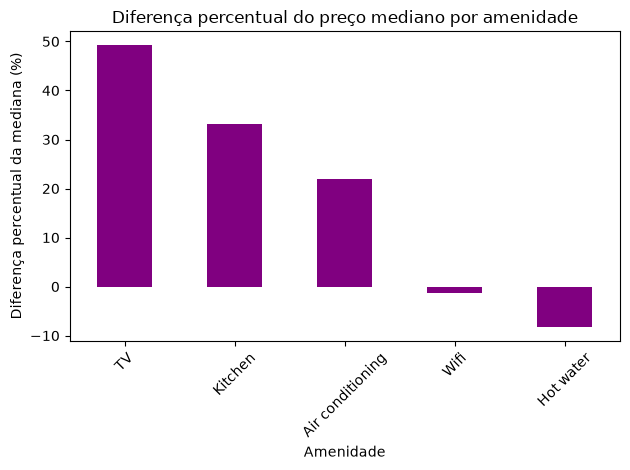

In [17]:
percentuais.plot(kind='bar', color='purple')

plt.xlabel('Amenidade')
plt.ylabel('Diferença percentual da mediana (%)')
plt.title('Diferença percentual do preço mediano por amenidade')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Análise aprofundada: A associação entre as amenidades e o preço das acomodações permanece quando controlamos por características da acomodação?

In [18]:
#Comparação entre acomodações com e sem TV
df['has_tv'] = df['amenities'].str.lower().str.contains('tv', na=False)
df['has_tv'] = df['has_tv'].map({True: 'Com TV', False: 'Sem TV'})
tabela_preco= pd.pivot_table(
    df,
    values='price', 
    index=['bedrooms'],
    columns=['has_tv'], 
    aggfunc='median' 
).round(2)
tabela_preco.index = tabela_preco.index.astype(int)
tabela_preco['Diferença (R$)'] = tabela_preco['Com TV'] - tabela_preco['Sem TV']
tabela_preco = tabela_preco.fillna('-')

tabela_volume = pd.pivot_table(
    df,
    values='price', 
    index=['bedrooms'],
    columns=['has_tv'],
    aggfunc='count' 
).fillna(0)
tabela_volume.index = tabela_volume.index.astype(int)
display(tabela_preco.head(7)) 
display(tabela_volume.head(7))

has_tv,Com TV,Sem TV,Diferença (R$)
bedrooms,,,
0,171.0,177.0,-6.0
1,388.0,288.75,99.25
2,649.33,609.34,39.99
3,1001.5,930.5,71.0
4,1872.92,1851.34,21.58
5,4767.0,3423.67,1343.33
6,5502.35,1142.0,4360.35


has_tv,Com TV,Sem TV
bedrooms,,
0,6.0,1.0
1,20940.0,2060.0
2,9405.0,600.0
3,3491.0,177.0
4,732.0,64.0
5,313.0,27.0
6,128.0,14.0


Pode se notar que, excluindo os estudios(bedrooms=0), há uma disparidade de preço meio inconsistente comparando exemplos com e sem tv.   
Vale resaltar que a quantidade de locais sem tv é muito abaixo da de locais com tv.   


Locais com apenas um quarto são os que possuem mais dados, onde a mediana retorna que há uma diferença de R$99 reais entre quartos com e sem TV.   
De dois a quatro quartos, a presença da TV afeta menos o preço, considerando que quartos a mais já adicionam um bom peso ao preço.   

Os ambientes com 5+ quartos são questionaveis a analise, pode se extrair que a falta de uma TV indica que outras qualidades também não estão presentes, levando a grande diferença de preço, porem devido a quantidade de dados, não pode se extrair muito mais do que isto.

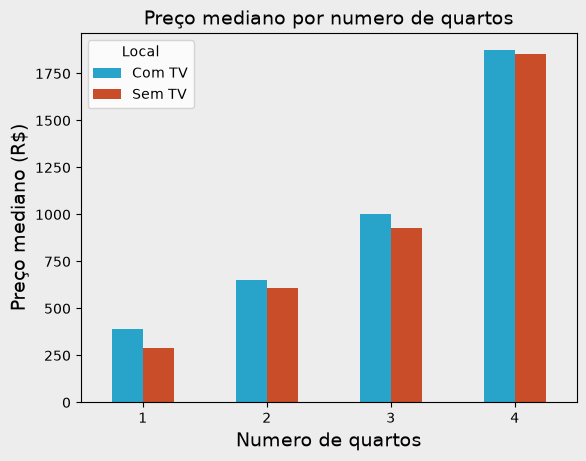

In [19]:
tabela_grafico = pd.pivot_table(
    df[(df['bedrooms'] >= 1) & (df['bedrooms'] <= 4)],
    values='price', 
    index=['bedrooms'],
    columns=['has_tv'], 
    aggfunc='median' 
)
tabela_grafico.index = tabela_grafico.index.astype(int)

#cores e medidas
ax = tabela_grafico.plot(kind='bar', width=0.5,color=["#28a3c9","#c94d28"])
ax.set_facecolor('#ededed') 
ax.figure.patch.set_facecolor('#ededed')

#plot do grafico
plt.title('Preço mediano por numero de quartos', fontsize=14)
plt.xlabel('Numero de quartos', fontsize=14)
plt.ylabel('Preço mediano (R$)', fontsize=14)
plt.legend(title='Local')
plt.xticks(rotation=0)
plt.show()

In [20]:
# 1. Tratar as colunas 'bedrooms' e 'bathrooms'
# Removemos as linhas que não têm informação de quarto OU de banheiro
df_analise = df.dropna(subset=['bedrooms', 'bathrooms']).copy()

# Quartos são números inteiros, banheiros podem ser decimais (1.5)
df_analise['bedrooms'] = df_analise['bedrooms'].astype(int)
df_analise['bathrooms'] = df_analise['bathrooms'].astype(float) # Garantindo o formato

# 2. Criar as colunas de TV
df_analise['has_tv'] = df_analise['amenities'].str.lower().str.contains('tv', na=False)
df_analise['has_tv'] = df_analise['has_tv'].map({True: 'Com TV', False: 'Sem TV'})

# 3. Tabela de Preço com o agrupamento triplo
tabela_preco = pd.pivot_table(
    df_analise,
    values='price', 
    index=['room_type', 'bedrooms', 'bathrooms'], # <-- Adicionamos banheiros aqui!
    columns=['has_tv'], 
    aggfunc='median' 
).round(2)

# Calculando a diferença
tabela_preco['Diferença (R$)'] = tabela_preco['Com TV'] - tabela_preco['Sem TV']
tabela_preco = tabela_preco.fillna('-')

# 4. Tabela de Volume com o agrupamento triplo
tabela_volume = pd.pivot_table(
    df_analise,
    values='price', 
    index=['room_type', 'bedrooms', 'bathrooms'], # <-- E aqui também!
    columns=['has_tv'],
    aggfunc='count' 
).fillna(0)

# Exibindo os resultados 
print("--- PREÇO MEDIANO E DIFERENÇA ---")
display(tabela_preco.head(50)) 

print("\n--- QUANTIDADE DE ANÚNCIOS ---")
display(tabela_volume.head(50))

--- PREÇO MEDIANO E DIFERENÇA ---


has_tv                               Com TV   Sem TV Diferença (R$)
room_type       bedrooms bathrooms                                 
Entire home/apt 1        0.5         340.67        -              -
                         1.0          381.5   342.67          38.83
                         1.5         536.58    628.0         -91.42
                         2.0          572.3    571.0            1.3
                         2.5         837.71        -              -
                         3.0         866.81   692.86         173.95
                         3.5              -  6059.67              -
                         4.0         699.97        -              -
                         6.0              -   3424.0              -
                         11.0        1883.0        -              -
                2        0.5          998.0        -              -
                         1.0          483.3   519.25         -35.95
                         1.5          628.0    638.0          -10.0
                         2.0          742.0   794.26         -52.26
                         2.5         923.28   1027.5        -104.22
                         3.0          913.5  1179.51        -266.01
                         3.5        1858.48   1458.0         400.48
                         4.0         893.34  8971.72       -8078.38
                         4.5         4565.0        -              -
                         5.0         1113.0   4065.0        -2952.0
                         7.0              -  5667.54              -
                3        0.5        1777.75        -              -
                         1.0         749.66   1142.0        -392.34
                         1.5          799.0    742.0           57.0
                         2.0          913.0   939.84         -26.84
                         2.5         1032.0    834.0          198.0
                         3.0        1186.72  1141.29          45.43
                         3.5        1527.19   1610.0         -82.81
                         4.0         1689.1  4326.88       -2637.78
                         4.5        2615.34   1142.0        1473.34
                         5.0        1928.14   4972.8       -3044.66
                         5.5        5216.07        -              -
                         6.0         1940.0        -              -
                         6.5         2853.0        -              -
                         7.0        3683.33        -              -
                4        0.5         4432.5        -              -
                         1.0        1008.25  1654.86        -646.61
                         1.5         939.84   1513.8        -573.96
                         2.0        1104.25  1671.92        -567.67
                         2.5        1331.39   4008.5       -2677.11
                         3.0         1695.0  2676.33        -981.33
                         3.5         1732.0  2510.67        -778.67
                         4.0         2387.6   2240.0          147.6
                         4.5         2735.5  9497.75       -6762.25
                         5.0         3195.3  3944.16        -748.86
                         5.5        6014.93        -              -
                         6.0        6042.75  3195.44        2847.31
                         6.5         5706.0        -              -
                         7.0        4371.18   3693.2         677.98
                         7.5        2963.33        -              -


--- QUANTIDADE DE ANÚNCIOS ---


has_tv                               Com TV  Sem TV
room_type       bedrooms bathrooms                 
Entire home/apt 1        0.5           15.0     0.0
                         1.0        16045.0  1025.0
                         1.5          499.0    23.0
                         2.0          742.0    45.0
                         2.5           20.0     0.0
                         3.0           22.0     3.0
                         3.5            0.0     1.0
                         4.0            2.0     0.0
                         6.0            0.0     1.0
                         11.0           1.0     0.0
                2        0.5           11.0     0.0
                         1.0         2908.0   206.0
                         1.5          724.0    43.0
                         2.0         4023.0   187.0
                         2.5          390.0    15.0
                         3.0          387.0    22.0
                         3.5           20.0     4.0
                         4.0           33.0     2.0
                         4.5            2.0     0.0
                         5.0            3.0     2.0
                         7.0            0.0     1.0
                3        0.5            4.0     0.0
                         1.0          190.0    15.0
                         1.5          136.0    13.0
                         2.0         1419.0    56.0
                         2.5          353.0    14.0
                         3.0          686.0    33.0
                         3.5          185.0     3.0
                         4.0          114.0     4.0
                         4.5           28.0     1.0
                         5.0           16.0     1.0
                         5.5            4.0     0.0
                         6.0            5.0     0.0
                         6.5            1.0     0.0
                         7.0            1.0     0.0
                4        0.5            2.0     0.0
                         1.0            6.0     2.0
                         1.5            6.0     1.0
                         2.0           78.0     6.0
                         2.5           51.0     4.0
                         3.0          133.0     8.0
                         3.5           73.0     5.0
                         4.0          104.0     7.0
                         4.5           62.0     4.0
                         5.0           43.0     6.0
                         5.5           26.0     0.0
                         6.0           34.0     2.0
                         6.5           10.0     0.0
                         7.0           10.0     2.0
                         7.5            3.0     0.0

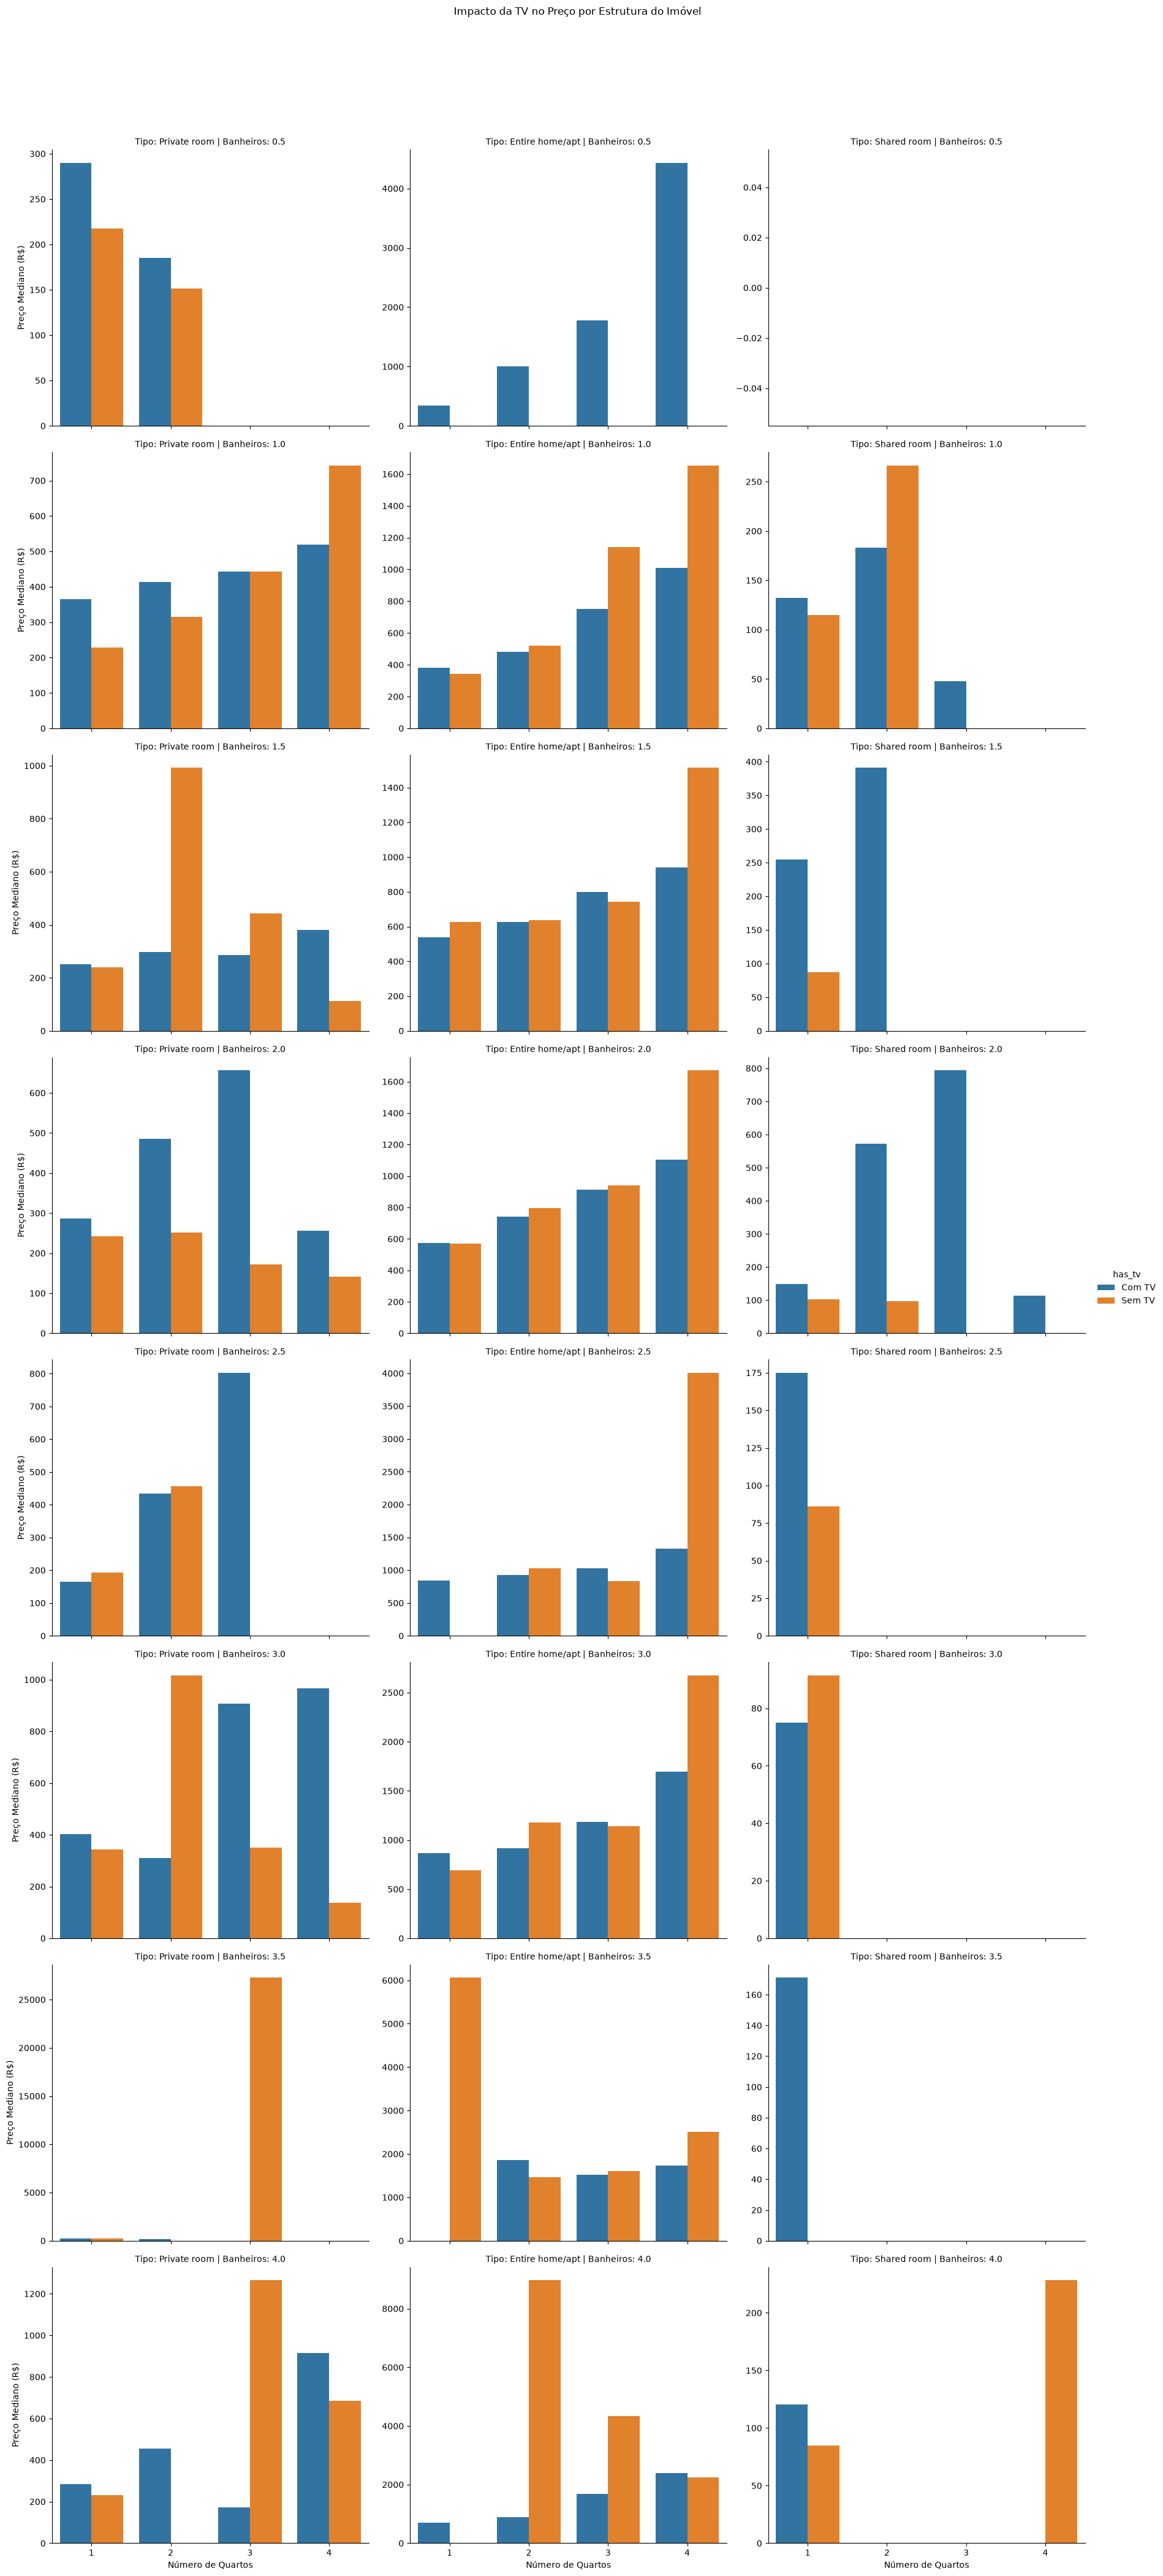

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vamos filtrar para não mostrar anúncios extremos (ex: 10 banheiros) que poluem o gráfico
df_grafico = df_analise[
    (df_analise['bedrooms'] >= 1) &
    (df_analise['room_type'] != 'Hotel room') &
    (df_analise['bedrooms'] <= 4) & 
    (df_analise['bathrooms'] <= 4)
]

# Criando o gráfico em grade
g = sns.catplot(
    data=df_grafico,
    x='bedrooms',           # Eixo X: Número de quartos
    y='price',              # Eixo Y: Preço
    hue='has_tv',           # Cores: Com ou Sem TV
    col='room_type',        # Divide em vários gráficos por Tipo de Quarto
    row='bathrooms',        # (Opcional) Divide em linhas por banheiros
    kind='bar',             # Tipo do gráfico: Barras
    estimator='median',     # Usa a mediana para ignorar outliers
    errorbar=None,          # Remove as linhas de erro para visualização mais limpa
    #height=4,               # Altura de cada sub-gráfico
    aspect=1.2,            # Proporção da largura
    sharey='row'
)

# Ajustando os títulos
g.set_axis_labels("Número de Quartos", "Preço Mediano (R$)")
g.set_titles("Tipo: {col_name} | Banheiros: {row_name}")
g.fig.suptitle('Impacto da TV no Preço por Estrutura do Imóvel', y=1.05)

plt.show()